# Combined EDA
## Exploratory Data Analysis on `combined.csv`

Questions addressed:
1. How many species have slippage?
2. How many clusters have slippage?
3. Median # of assemblies per species? per cluster?
4. Location of slippage — where is it, # and % compared to full sequence length
5. Is slippage homogenous within clusters?
6. Proportion for subsetting Influenza A vs other species

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 6)})

## 1. Load Data

In [3]:
df = pd.read_csv('../combined.csv')
combined = pd.read_csv('../combined.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (124878, 26)
Columns: ['Unnamed: 0', 'record_id', 'strand', 'source_file', 'search_term', 'type', 'n_segments', 'qualifiers', 'exception', 'start1', 'end1', 'start2', 'end2', 'slippage_site', 'slippage_direction', 'cluster', 'accession', 'mol_type', 'assembly_level', 'assembly_name', 'submitter', 'total_sequence_length', 'gc_percent', 'taxid', 'organism_name', 'release_date']


,Unnamed: 0,record_id,strand,source_file,search_term,type,n_segments,qualifiers,exception,start1,...,accession,mol_type,assembly_level,assembly_name,submitter,total_sequence_length,gc_percent,taxid,organism_name,release_date
0,0,AB033998.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-BAA92848.1'], 'Dbxref': ['NCBI_GP...",ribosomal slippage,13,...,GCA_000852205.1,genomic RNA,Complete Genome,ViralProj14804,"Tadao Imada, National Institute of Animal Heal...",6927,46.5,336960,Avian nephritis virus 1,2000-03-22
1,1,AB523788.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-BAI77525.1'], 'Dbxref': ['NCBI_GP...",ribosomal slippage,73,...,GCA_000898355.1,genomic RNA,Complete Genome,ViralMultiSegProj170929,Contact:Mitsuru Okuda National Agricultural Re...,16648,36.5,558690,Cucurbit chlorotic yellows virus,2010-02-23
2,2,AB594828.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-BAJ72195.1'], 'Parent': ['gene-OR...",ribosomal slippage,175,...,GCA_000891555.1,genomic RNA,Complete Genome,ViralProj62493,Contact:Ritsuko Murakami National Institute of...,6244,49.5,909827,Pepper vein yellows virus,2011-02-01


4194

In [3]:
# Quick overview
print(f"Unique species (organism_name): {df['organism_name'].nunique()}")
print(f"Unique clusters:               {df['cluster'].nunique()}")
print(f"Unique accessions:             {df['accession'].nunique()}")
print(f"Total records:                 {len(df)}")
print(f"\nNull counts:")
print(df.isnull().sum())

Unique species (organism_name): 27012
Unique clusters:               4194
Unique accessions:             124876
Total records:                 124878

Null counts:
Unnamed: 0               0
record_id                0
strand                   0
source_file              0
search_term              0
type                     0
n_segments               0
qualifiers               0
exception                0
start1                   0
end1                     0
start2                   0
end2                     0
slippage_site            0
slippage_direction       0
cluster                  0
accession                0
mol_type                 0
assembly_level           0
assembly_name            0
submitter                4
total_sequence_length    0
gc_percent               0
taxid                    0
organism_name            0
release_date             0
dtype: int64


---
## 2. How many species have slippage?

Since `combined.csv` only contains records WITH slippage annotations, every species in this dataset has at least one slippage event.

In [4]:
n_species_with_slippage = df['organism_name'].nunique()
print(f"Number of species with slippage: {n_species_with_slippage:,}")

# Top 20 species by number of slippage records
species_counts = df['organism_name'].value_counts()
print(f"\nTop 20 species by # of slippage records:")
print(species_counts.head(20))

Number of species with slippage: 27,012

Top 20 species by # of slippage records:
organism_name
Influenza A virus                                  95149
Severe acute respiratory syndrome coronavirus 2       84
Porcine epidemic diarrhea virus                       44
Human immunodeficiency virus 1                         8
Influenza A virus (A/Texas/71/2017(H3N2))              5
Influenza A virus (A/Iowa/53/2015(H1N1))               5
Pepper vein yellows virus                              4
Influenza A virus (A/California/07/2009(H1N1))         4
Influenza A virus (A/Montana/50/2016(H1N1))            4
Influenza A virus (A/Oregon/19/2016(H3N2))             4
Influenza A virus (A/Wisconsin/19/2017(H3N2))          4
Influenza A virus (A/Michigan/272/2017(H1N1))          4
Porcine coronavirus HKU15                              4
Influenza A virus (A/New York/61/2015(H1N1))           4
Influenza A virus (A/Michigan/45/2015(H1N1))           4
Influenza A virus (A/Minnesota/45/2015(H1N1))    

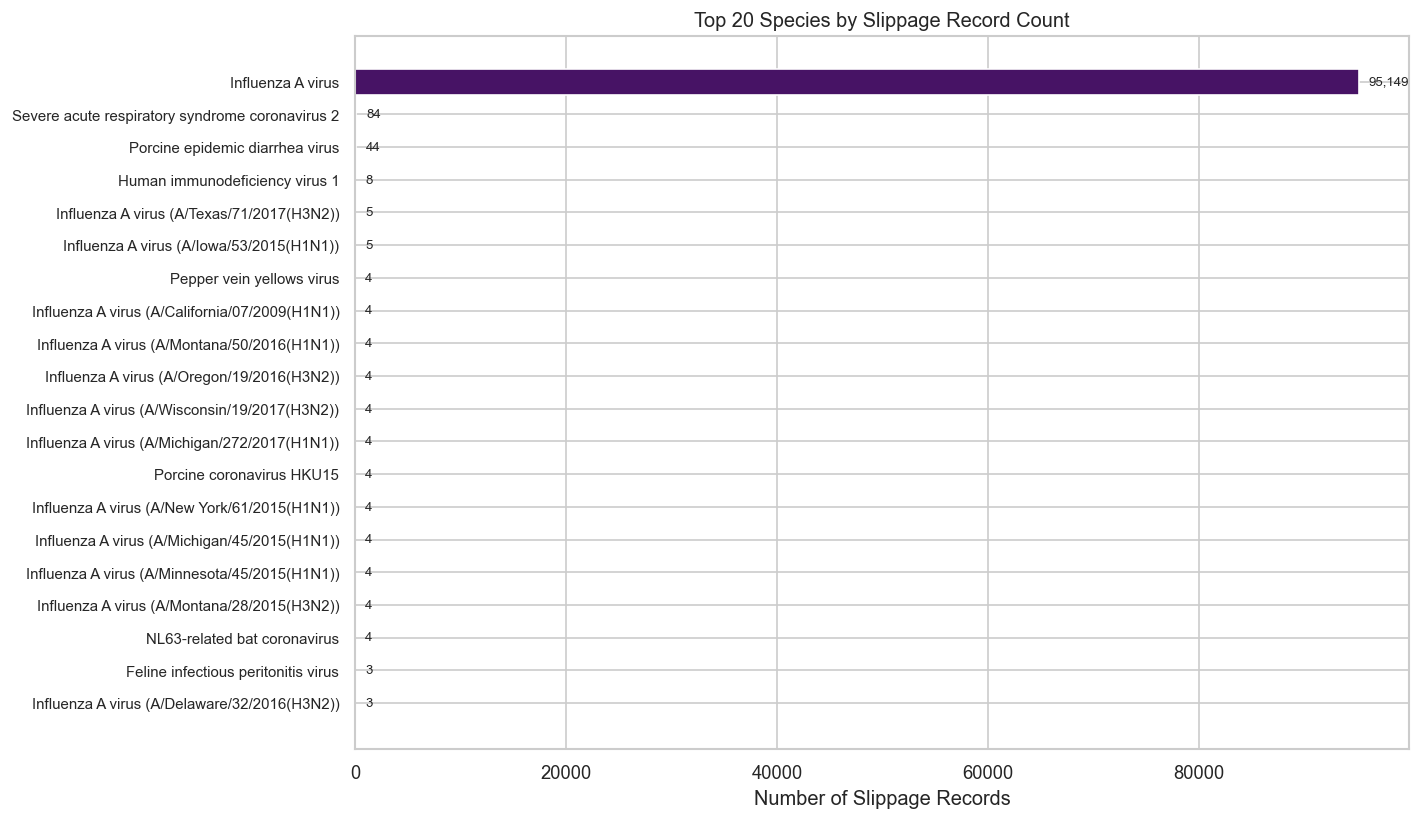

In [5]:
# Bar chart: top 20 species by slippage count
top20 = species_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top20)), top20.values, color=sns.color_palette("viridis", len(top20)))
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of Slippage Records")
ax.set_title("Top 20 Species by Slippage Record Count")
for i, (bar, count) in enumerate(zip(bars, top20.values)):
    ax.text(bar.get_width() + max(top20.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. How many clusters have slippage?

In [37]:
n_clusters_with_slippage = df['cluster'].nunique()
print(f"Number of clusters with slippage: {n_clusters_with_slippage:,}")

# Top clusters by slippage record count
cluster_counts = df['cluster'].value_counts()
cluster_counts.index = cluster_counts.index.map(
    df.drop_duplicates('cluster').set_index('cluster')['organism_name']
)

print(f"\nTop 20 clusters by # of slippage records:")
print(cluster_counts.head(20))

Number of clusters with slippage: 4,194

Top 20 clusters by # of slippage records:
cluster
Influenza A virus (A/New York/392/2004(H3N2))                             45426
Influenza A virus (A/Barcelona/INS378/2009(H1N1))                         30168
Influenza A virus (A/duck/Mongolia/543/2015(H4N6))                         9312
Influenza A virus (A/ruddy turnstone/Delaware Bay/124/2007(H7N3))          4867
Influenza A virus (A/mallard/New Zealand/479-8/2005(H6N2))                 4558
Influenza A virus (A/duck/Hunan/S4111/2011(H9N2))                          4018
Influenza A virus (A/swine/Arkansas/SG1157/2003(H1N1))                     3235
Influenza A virus (A/blue-winged teal/Louisiana/Sg-00073/2007(H10N7))      3173
Influenza A virus (A/green-winged teal/Ohio/430/1987(H1N1))                1349
Influenza A virus (A/green winged teal/California/AKS1305/2008(H11N9))     1029
Influenza A virus (A/swine/Spain/51915/2003(H1N1))                          969
Influenza A virus (A/duck/Hun

NameError: name 'combined' is not defined

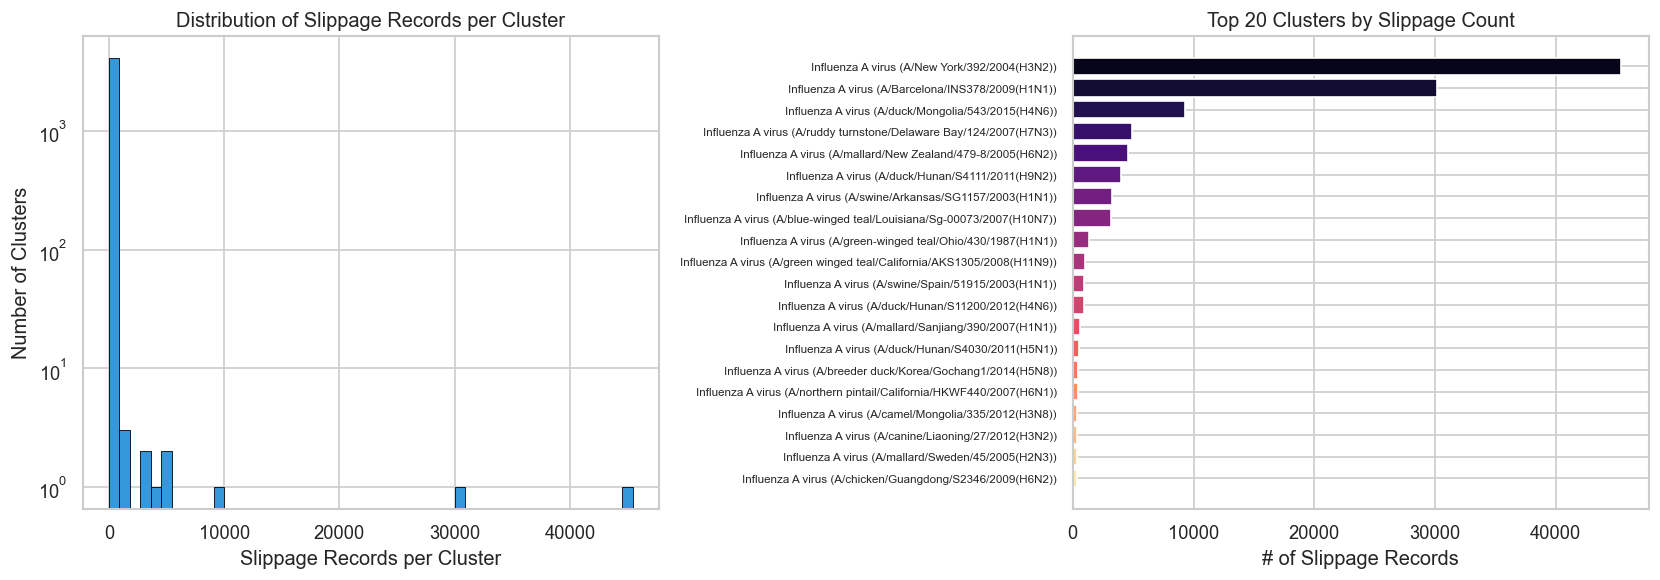

In [38]:
# Distribution of slippage records per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(cluster_counts.values, bins=50, color="#3498db", edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Slippage Records per Cluster")
axes[0].set_ylabel("Number of Clusters")
axes[0].set_title("Distribution of Slippage Records per Cluster")
axes[0].set_yscale('log')

# Top 20 clusters bar
top20_cl = cluster_counts.head(20)
axes[1].barh(range(len(top20_cl)), top20_cl.values, color=sns.color_palette("magma", len(top20_cl)))
axes[1].set_yticks(range(len(top20_cl)))
axes[1].set_yticklabels(top20_cl.index, fontsize=7)
axes[1].invert_yaxis()
axes[1].set_xlabel("# of Slippage Records")
axes[1].set_title("Top 20 Clusters by Slippage Count")

plt.tight_layout()
plt.show()

---
## 4. Median # of assemblies per species? Per cluster?

In [8]:
# Assemblies per species: count unique accessions per organism_name
asm_per_species = df.groupby('organism_name')['accession'].nunique()

print("Assemblies per species (with slippage):")
print(f"  Mean:   {asm_per_species.mean():.2f}")
print(f"  Median: {asm_per_species.median():.1f}")
print(f"  Min:    {asm_per_species.min()}")
print(f"  Max:    {asm_per_species.max()}")
print(f"  Std:    {asm_per_species.std():.2f}")
print(f"\n  Quartiles:")
print(asm_per_species.describe())

Assemblies per species (with slippage):
  Mean:   4.62
  Median: 1.0
  Min:    1
  Max:    95149
  Std:    578.92

  Quartiles:
count    27012.000000
mean         4.622982
std        578.923402
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      95149.000000
Name: accession, dtype: float64


In [9]:
# Assemblies per cluster: count unique accessions per cluster
asm_per_cluster = df.groupby('cluster')['accession'].nunique()

print("Assemblies per cluster (with slippage):")
print(f"  Mean:   {asm_per_cluster.mean():.2f}")
print(f"  Median: {asm_per_cluster.median():.1f}")
print(f"  Min:    {asm_per_cluster.min()}")
print(f"  Max:    {asm_per_cluster.max()}")
print(f"  Std:    {asm_per_cluster.std():.2f}")
print(f"\n  Quartiles:")
print(asm_per_cluster.describe())

Assemblies per cluster (with slippage):
  Mean:   29.78
  Median: 1.0
  Min:    1
  Max:    45426
  Std:    866.00

  Quartiles:
count     4194.000000
mean        29.775393
std        866.004781
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max      45426.000000
Name: accession, dtype: float64


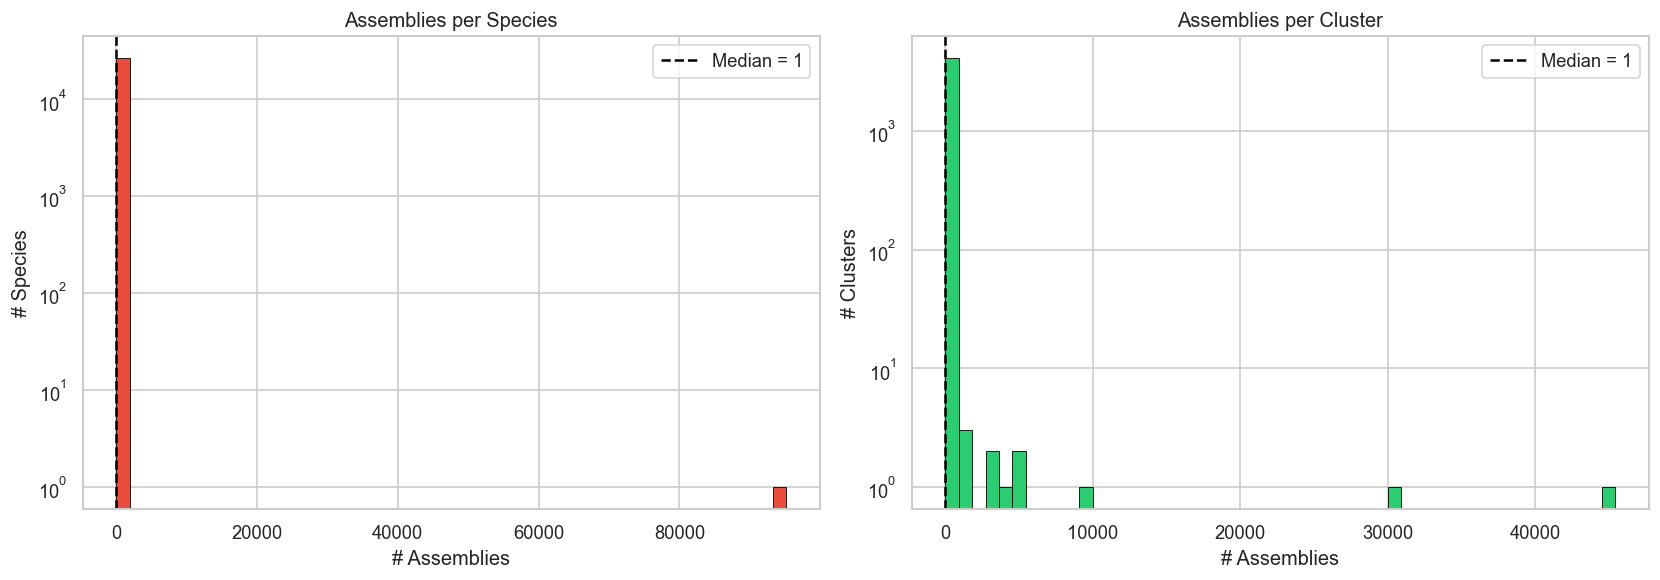

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Assemblies per species
axes[0].hist(asm_per_species.values, bins=50, color="#e74c3c", edgecolor="black", linewidth=0.5)
axes[0].axvline(asm_per_species.median(), color='black', linestyle='--',
                label=f'Median = {asm_per_species.median():.0f}')
axes[0].set_xlabel("# Assemblies")
axes[0].set_ylabel("# Species")
axes[0].set_title("Assemblies per Species")
axes[0].set_yscale('log')
axes[0].legend()

# Assemblies per cluster
axes[1].hist(asm_per_cluster.values, bins=50, color="#2ecc71", edgecolor="black", linewidth=0.5)
axes[1].axvline(asm_per_cluster.median(), color='black', linestyle='--',
                label=f'Median = {asm_per_cluster.median():.0f}')
axes[1].set_xlabel("# Assemblies")
axes[1].set_ylabel("# Clusters")
axes[1].set_title("Assemblies per Cluster")
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

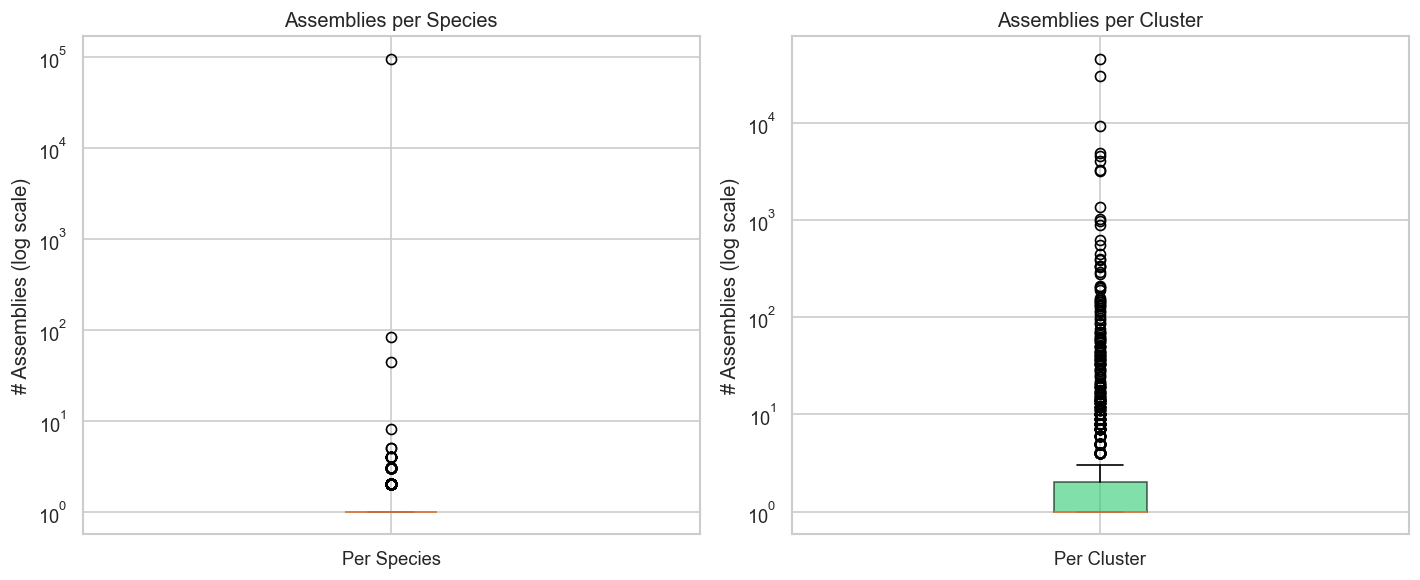

In [11]:
# Box plots (log scale) for assemblies per species and cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bp1 = axes[0].boxplot([asm_per_species.values], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#e74c3c', alpha=0.6))
axes[0].set_ylabel("# Assemblies (log scale)")
axes[0].set_title("Assemblies per Species")
axes[0].set_yscale('log')
axes[0].set_xticklabels(['Per Species'])

bp2 = axes[1].boxplot([asm_per_cluster.values], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#2ecc71', alpha=0.6))
axes[1].set_ylabel("# Assemblies (log scale)")
axes[1].set_title("Assemblies per Cluster")
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Per Cluster'])

plt.tight_layout()
plt.show()

---
## 5. Location of slippage

Where does slippage occur relative to the full sequence length? Plot absolute position and fractional position (slippage_site / total_sequence_length).

In [66]:
# Compute fractional slippage location
df['slippage_frac'] = df['slippage_site'] / df['total_sequence_length']

print("Slippage site (absolute) statistics:")
print(df['slippage_site'].describe())
print(f"\nSlippage site as fraction of total sequence length:")
print(df['slippage_frac'].describe())
print(f"\nTotal sequence length statistics:")
print(df['total_sequence_length'].describe())

Slippage site (absolute) statistics:
count    124878.000000
mean       1233.412499
std        4299.694786
min          12.000000
25%         570.000000
50%         582.000000
75%         582.000000
max      117718.000000
Name: slippage_site, dtype: float64

Slippage site as fraction of total sequence length:
count    124878.000000
mean          0.054034
std           0.055877
min           0.001125
25%           0.043345
50%           0.043392
75%           0.043432
max           0.986767
Name: slippage_frac, dtype: float64

Total sequence length statistics:
count    124878.000000
mean      15056.951753
std       10767.344648
min        2692.000000
25%       13136.000000
50%       13379.000000
75%       13432.000000
max      376207.000000
Name: total_sequence_length, dtype: float64


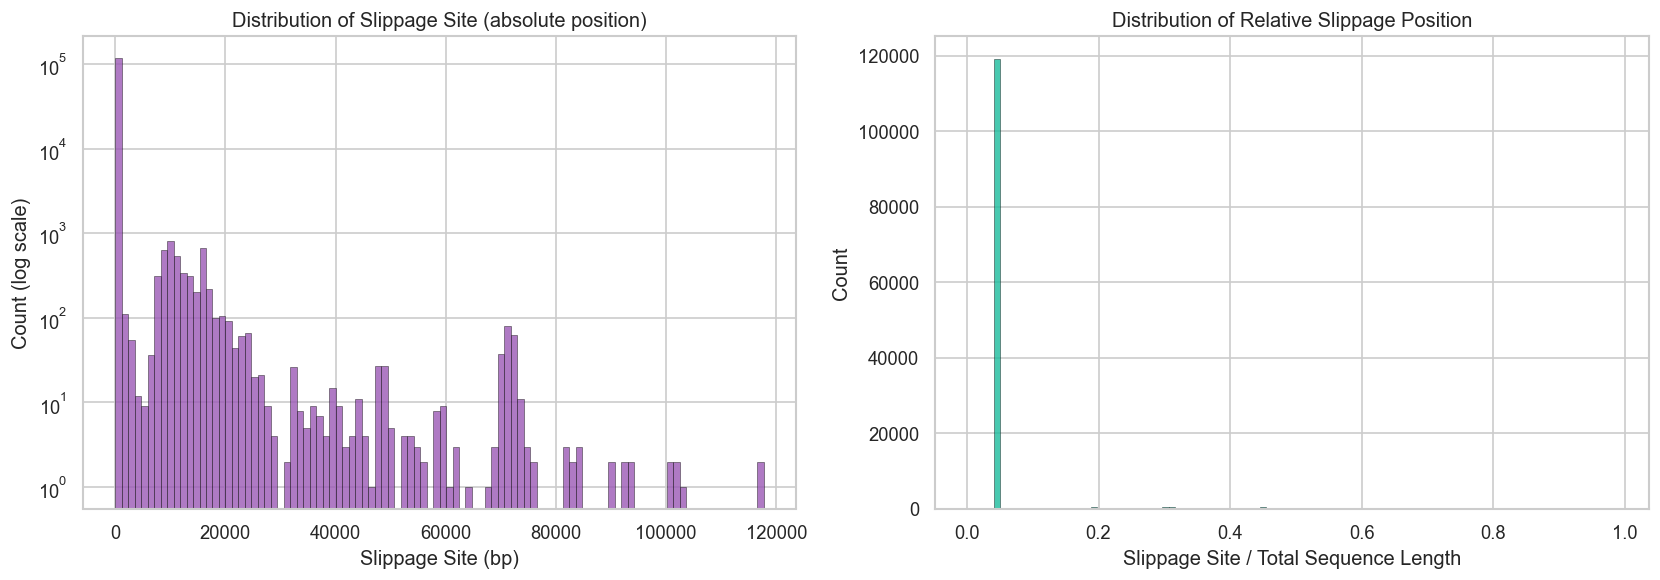

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute slippage site
axes[0].hist(df['slippage_site'].values, bins=100, color="#9b59b6", edgecolor="black", linewidth=0.3, alpha=0.8)
axes[0].set_xlabel("Slippage Site (bp)")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Distribution of Slippage Site (absolute position)")
axes[0].set_yscale('log')

# Fractional slippage location
axes[1].hist(df['slippage_frac'].values, bins=100, color="#1abc9c", edgecolor="black", linewidth=0.3, alpha=0.8)
axes[1].set_xlabel("Slippage Site / Total Sequence Length")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Relative Slippage Position")

plt.tight_layout()
plt.show()

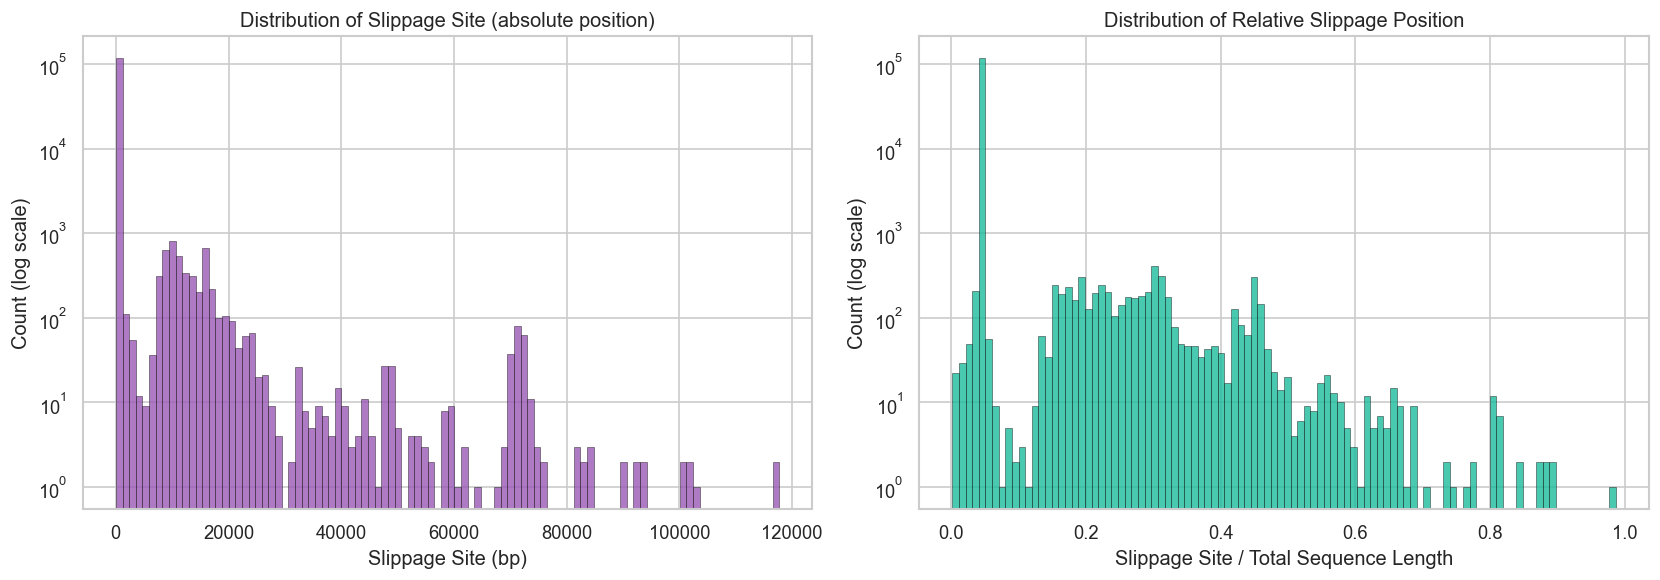

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute slippage site
axes[0].hist(df['slippage_site'].values, bins=100, color="#9b59b6", edgecolor="black", linewidth=0.3, alpha=0.8)
axes[0].set_xlabel("Slippage Site (bp)")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Distribution of Slippage Site (absolute position)")
axes[0].set_yscale('log')

# Fractional slippage location
axes[1].hist(df['slippage_frac'].values, bins=100, color="#1abc9c", edgecolor="black", linewidth=0.3, alpha=0.8)
axes[1].set_xlabel("Slippage Site / Total Sequence Length")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("Distribution of Relative Slippage Position")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

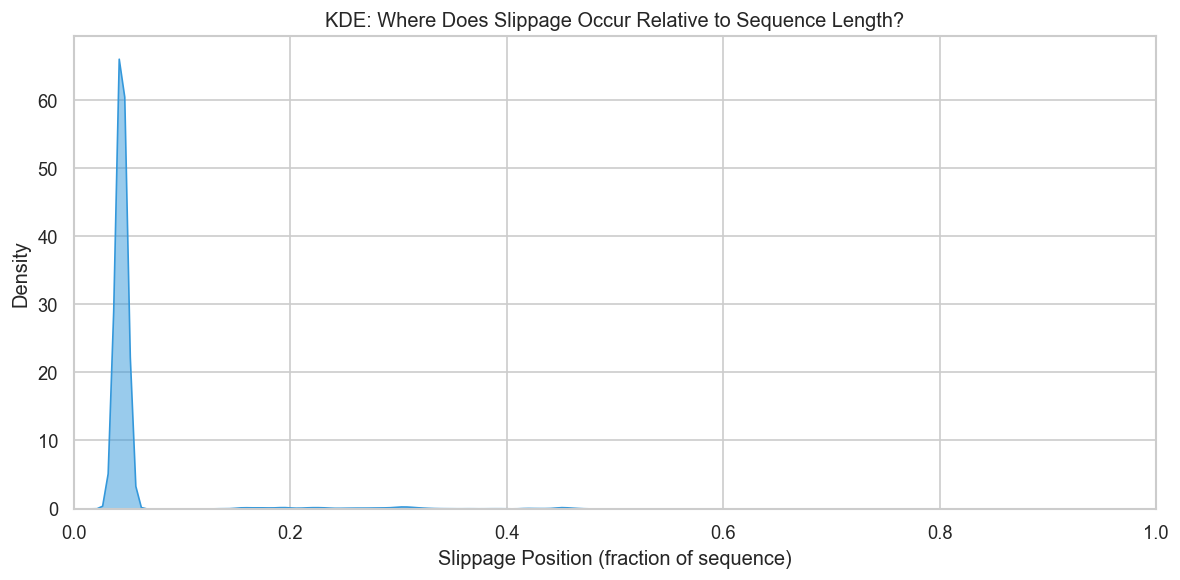

In [ ]:
# KDE of fractional slippage position
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='slippage_frac', fill=True, color='#3498db', alpha=0.5, ax=ax)
ax.set_xlabel("Slippage Position (fraction of sequence)")
ax.set_title("KDE: Where Does Slippage Occur Relative to Sequence Length?")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

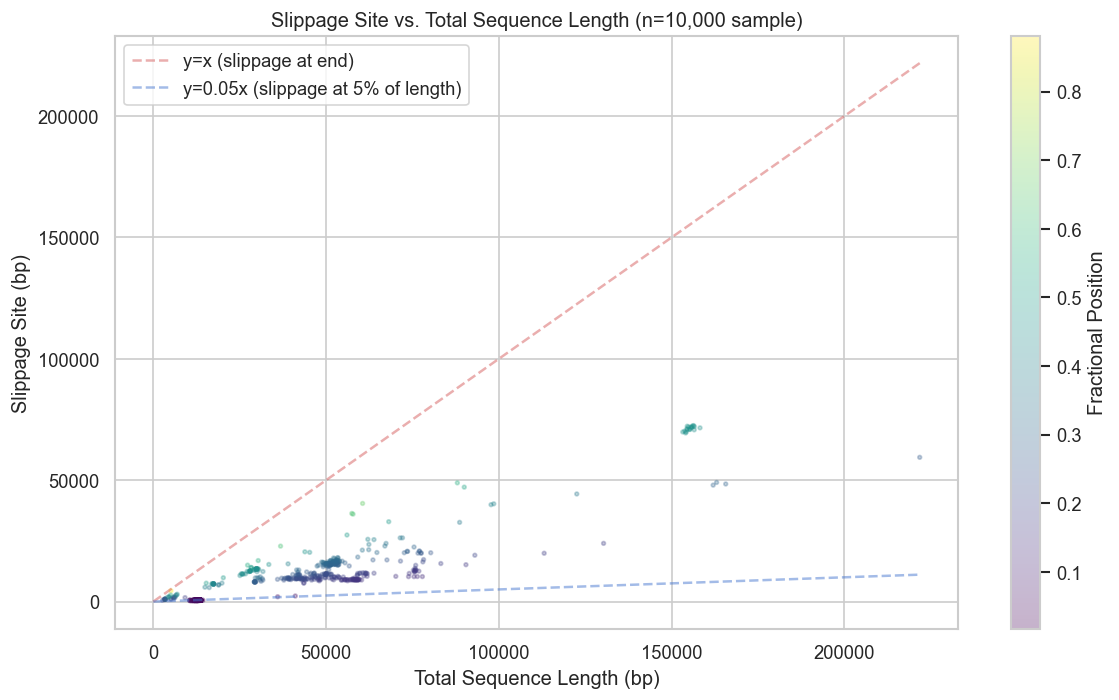

In [73]:
# Scatter: slippage_site vs total_sequence_length (sample for performance)
sample = df.sample(n=min(10000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(sample['total_sequence_length'], sample['slippage_site'],
                alpha=0.3, s=5, c=sample['slippage_frac'], cmap='viridis')
# diagonal reference line (y=x)
lim = max(sample['total_sequence_length'].max(), sample['slippage_site'].max())
ax.plot([0, lim], [0, lim], 'r--', alpha=0.5, label='y=x (slippage at end)')
ax.plot([0, lim], [0, 0.05 * lim], '--', alpha=0.5, label='y=0.05x (slippage at 5% of length)')
ax.set_xlabel("Total Sequence Length (bp)")
ax.set_ylabel("Slippage Site (bp)")
ax.set_title("Slippage Site vs. Total Sequence Length (n=10,000 sample)")
plt.colorbar(sc, label='Fractional Position')
ax.legend()
plt.tight_layout()
plt.show()

Slippage count and % by position bin:
          Count  Percent
pos_bin                 
0-10%    119577    95.76
10-20%     1247     1.00
20-30%     1740     1.39
30-40%     1242     0.99
40-50%      857     0.69
50-60%      113     0.09
60-70%       67     0.05
70-80%        7     0.01
80-90%       25     0.02
90-100%       3     0.00


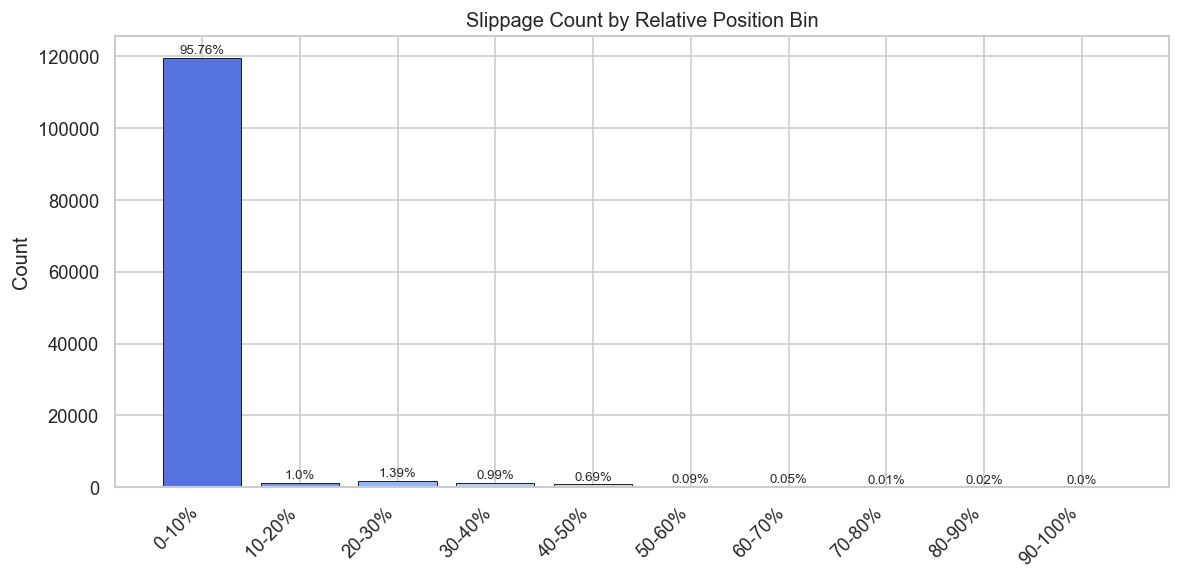

In [ ]:
# Binned position analysis: divide sequence into 10 bins, count slippage in each
df['pos_bin'] = pd.cut(df['slippage_frac'], bins=10, labels=[
    '0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
])

bin_counts = df['pos_bin'].value_counts().sort_index()
bin_pct = (bin_counts / len(df) * 100).round(2)

print("Slippage count and % by position bin:")
summary = pd.DataFrame({'Count': bin_counts, 'Percent': bin_pct})
print(summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(bin_counts)), bin_counts.values, color=sns.color_palette('coolwarm', len(bin_counts)),
       edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(bin_counts)))
ax.set_xticklabels(bin_counts.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Slippage Count by Relative Position Bin')
for i, (cnt, pct) in enumerate(zip(bin_counts.values, bin_pct.values)):
    ax.text(i, cnt + max(bin_counts.values) * 0.01, f"{pct}%", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Is slippage homogenous within clusters?

For each cluster ID, do ALL assemblies in that cluster have slippage, or only SOME?

To answer this, we need to know the total assemblies per cluster (from the full dataset), not just those with slippage. We load the clustering results and compare.

In [ ]:
# Load the full cluster data to get total members per cluster
cluster_full = pd.read_csv('../clustering_results/clusterRes_cluster.tsv',
                           sep='\t', names=['cluster', 'ID'])
cluster_full = cluster_full.drop_duplicates(['cluster', 'ID'])

# Total members per cluster (from full dataset)
total_per_cluster = cluster_full.groupby('cluster')['ID'].nunique().rename('total_members')

# Members with slippage per cluster (from combined.csv)
# Use record_id as proxy for the sequence-level ID within each cluster
slip_per_cluster = df.groupby('cluster')['record_id'].nunique().rename('slip_members')

# Merge
cluster_homo = pd.DataFrame(total_per_cluster).join(slip_per_cluster, how='left')
cluster_homo['slip_members'] = cluster_homo['slip_members'].fillna(0).astype(int)
cluster_homo['slip_fraction'] = cluster_homo['slip_members'] / cluster_homo['total_members']

print(f"Total clusters in full dataset: {len(cluster_homo):,}")
print(f"Clusters with any slippage:     {(cluster_homo['slip_members'] > 0).sum():,}")
print(f"Clusters with NO slippage:      {(cluster_homo['slip_members'] == 0).sum():,}")
print()

# Classify clusters
cluster_homo['category'] = 'Mixed'
cluster_homo.loc[cluster_homo['slip_fraction'] == 0, 'category'] = 'No Slippage'
cluster_homo.loc[cluster_homo['slip_fraction'] == 1, 'category'] = 'All Slippage'

cat_counts = cluster_homo['category'].value_counts()
print("Cluster homogeneity:")
print(cat_counts)
print(f"\n% homogeneous (all or none): {((cat_counts.get('All Slippage', 0) + cat_counts.get('No Slippage', 0)) / len(cluster_homo) * 100):.1f}%")
print(f"% mixed:                     {(cat_counts.get('Mixed', 0) / len(cluster_homo) * 100):.1f}%")

Total clusters in full dataset: 50,057
Clusters with any slippage:     4,194
Clusters with NO slippage:      45,863

Cluster homogeneity:
category
No Slippage     45863
All Slippage     3988
Mixed             206
Name: count, dtype: int64

% homogeneous (all or none): 99.6%
% mixed:                     0.4%


In [ ]:
mixed_clusters = cluster_homo[cluster_homo['category'] == 'Mixed']
print(f"Mixed clusters: {len(mixed_clusters):,}")
mixed_clusters.sort_values('slip_fraction', ascending=False)

Mixed clusters: 206


,total_members,slip_members,slip_fraction,category
cluster,,,,
OR269886.1,9386,9312,0.992116,Mixed
PP445473.1,114,113,0.991228,Mixed
MT378909.1,107,106,0.990654,Mixed
MW159331.1,281,278,0.989324,Mixed
MZ015695.1,77,76,0.987013,Mixed
...,...,...,...,...
JX138516.1,216,8,0.037037,Mixed
AP014841.1,63,1,0.015873,Mixed
KT970440.1,109,1,0.009174,Mixed


In [ ]:
df[df['cluster'] == 'JX138516.1']

,Unnamed: 0,record_id,strand,source_file,search_term,type,n_segments,qualifiers,exception,start1,...,assembly_level,assembly_name,submitter,total_sequence_length,gc_percent,taxid,organism_name,release_date,slippage_frac,pos_bin
1830,1830,CY147419.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-AGQ47878.1'], 'Parent': ['gene-PA...",ribosomal slippage,12,...,Complete Genome,ASM3792080v1,"on behalf of JCVI/NIAID/NCBI, National Center ...",13342,42.5,1343801,Influenza A virus (A/New Jersey/Swiss/1976(H1N1)),2013-07-12,0.043622,0-10%
3947,3947,CY177477.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-AHN00736.1'], 'Parent': ['gene-PA...",ribosomal slippage,0,...,Complete Genome,ASM3792168v1,J Craig Venter Institute,13247,42.5,1406555,Influenza A virus (A/swine/Wisconsin/46/1976(H...,2014-03-20,0.035253,0-10%
4083,4083,CY178708.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-AHN00748.1'], 'Parent': ['gene-PA...",ribosomal slippage,7,...,Complete Genome,ASM3792169v1,J Craig Venter Institute,13383,42.5,1406556,Influenza A virus (A/swine/Wisconsin/49/1976(H...,2014-03-20,0.043114,0-10%
4084,4084,CY178716.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-AHN00760.1'], 'Parent': ['gene-PA...",ribosomal slippage,7,...,Complete Genome,ASM3792164v1,J Craig Venter Institute,13364,42.5,1406554,Influenza A virus (A/swine/Wisconsin/11/1976(H...,2014-03-20,0.043176,0-10%
4406,4406,CY181374.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-AHN04974.1'], 'Parent': ['gene-PA...",ribosomal slippage,0,...,Complete Genome,ASM3793992v1,J Craig Venter Institute,13375,42.5,1445068,Influenza A virus (A/green-winged teal/Wiscons...,2014-03-20,0.042617,0-10%
10859,10859,EU735799.3,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-YCP19025.1'], 'Parent': ['gene-PA...",ribosomal slippage,24,...,Complete Genome,ASM3815961v1,"Southeast Poultry Research Laboratory, USDA Ag...",13602,42.5,11320,Influenza A virus,2026-01-26,0.043670,0-10%
11701,11701,KF057110.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-AGN69277.1'], 'Parent': ['gene-PA...",ribosomal slippage,0,...,Complete Genome,ASM3815916v1,"National Influenza Center, National Institute ...",13133,42.5,1335634,Influenza A virus (A/swine/Beijing/156/1991(H1...,2013-06-10,0.043402,0-10%
11702,11702,KF057111.1,1,../viral_data_all/ncbi_dataset/data_subset/GCA...,slip,CDS,2,"{'ID': ['cds-AGN69266.1'], 'Parent': ['gene-PA...",ribosomal slippage,0,...,Complete Genome,ASM3816050v1,"National Influenza Center, National Institute ...",13133,42.5,1335635,Influenza A virus (A/swine/Beijing/216/1992(H1...,2013-06-10,0.043402,0-10%


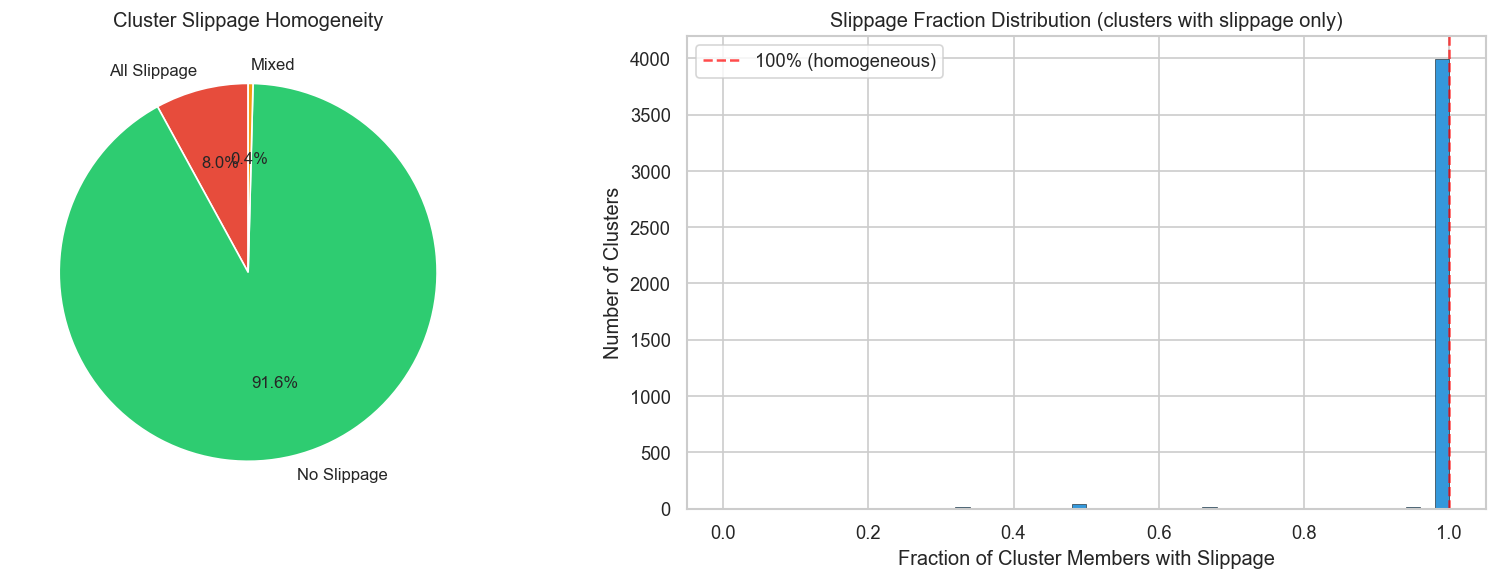

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of cluster categories
colors_pie = ['#e74c3c', '#2ecc71', '#f39c12']
cat_order = ['All Slippage', 'No Slippage', 'Mixed']
cat_vals = [cat_counts.get(c, 0) for c in cat_order]
axes[0].pie(cat_vals, labels=cat_order, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Cluster Slippage Homogeneity')

# Distribution of slip_fraction for clusters with any slippage
has_slip = cluster_homo[cluster_homo['slip_members'] > 0]
axes[1].hist(has_slip['slip_fraction'].values, bins=50, color='#3498db', edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('Fraction of Cluster Members with Slippage')
axes[1].set_ylabel('Number of Clusters')
axes[1].set_title('Slippage Fraction Distribution (clusters with slippage only)')
axes[1].axvline(1.0, color='red', linestyle='--', label='100% (homogeneous)', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Detailed statistics on mixed clusters
mixed = cluster_homo[cluster_homo['category'] == 'Mixed']

print(f"Mixed clusters: {len(mixed):,}")
print(f"\nSlippage fraction in mixed clusters:")
print(mixed['slip_fraction'].describe())
print(f"\nExamples of mixed clusters (showing first 10):")
print(mixed.head(10))

Mixed clusters: 206

Slippage fraction in mixed clusters:
count    206.000000
mean       0.542430
std        0.270244
min        0.000046
25%        0.333333
50%        0.500000
75%        0.766147
max        0.992116
Name: slip_fraction, dtype: float64

Examples of mixed clusters (showing first 10):
            total_members  slip_members  slip_fraction category
cluster                                                        
AB253429.1              2             1       0.500000    Mixed
AB781660.1              5             2       0.400000    Mixed
AF033819.3              3             1       0.333333    Mixed
AF068845.1              2             1       0.500000    Mixed
AF069308.1              2             1       0.500000    Mixed
AF083977.1              3             1       0.333333    Mixed
AF144302.1              4             1       0.250000    Mixed
AF304460.1              3             1       0.333333    Mixed
AP014841.1             63             1       0.015873    

---
## 7. Influenza A proportion — subsetting strategy

How dominant is Influenza A in the dataset? What proportion should we use to subset it compared to other species?

In [ ]:
is_flu_a = df['organism_name'] == 'Influenza A virus'
n_flu = is_flu_a.sum()
n_total = len(df)
n_other = n_total - n_flu

print(f"Influenza A virus records: {n_flu:,} ({n_flu/n_total*100:.1f}%)")
print(f"All other species records: {n_other:,} ({n_other/n_total*100:.1f}%)")
print(f"Total records:            {n_total:,}")

# Flu A unique assemblies
flu_asm = df[is_flu_a]['accession'].nunique()
other_asm = df[~is_flu_a]['accession'].nunique()
total_asm = df['accession'].nunique()

print(f"\nInfluenza A unique assemblies: {flu_asm:,} ({flu_asm/total_asm*100:.1f}%)")
print(f"Other species unique assemblies: {other_asm:,} ({other_asm/total_asm*100:.1f}%)")

# Flu A unique species count
flu_species = 1
other_species = df[~is_flu_a]['organism_name'].nunique()
print(f"\nFlu A is 1 species out of {df['organism_name'].nunique():,} total species")

Influenza A virus records: 95,149 (76.2%)
All other species records: 29,729 (23.8%)
Total records:            124,878

Influenza A unique assemblies: 95,149 (76.2%)
Other species unique assemblies: 29,727 (23.8%)

Flu A is 1 species out of 27,012 total species


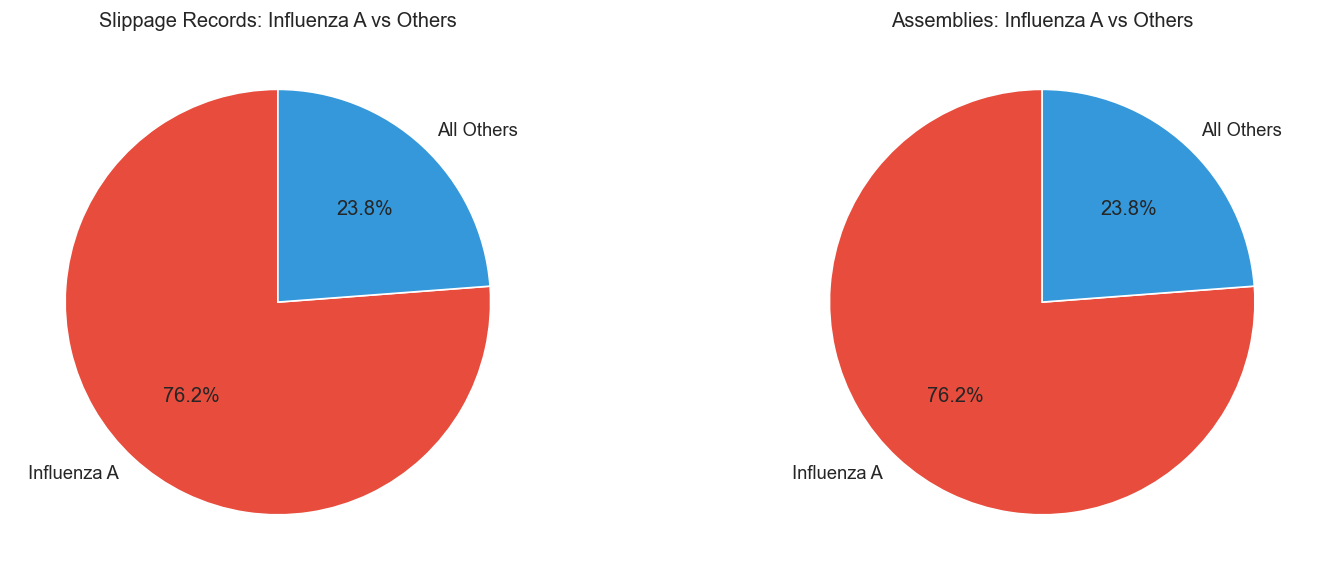

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records pie
axes[0].pie([n_flu, n_other], labels=['Influenza A', 'All Others'],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Slippage Records: Influenza A vs Others')

# Assemblies pie
axes[1].pie([flu_asm, other_asm], labels=['Influenza A', 'All Others'],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Assemblies: Influenza A vs Others')

plt.tight_layout()
plt.show()

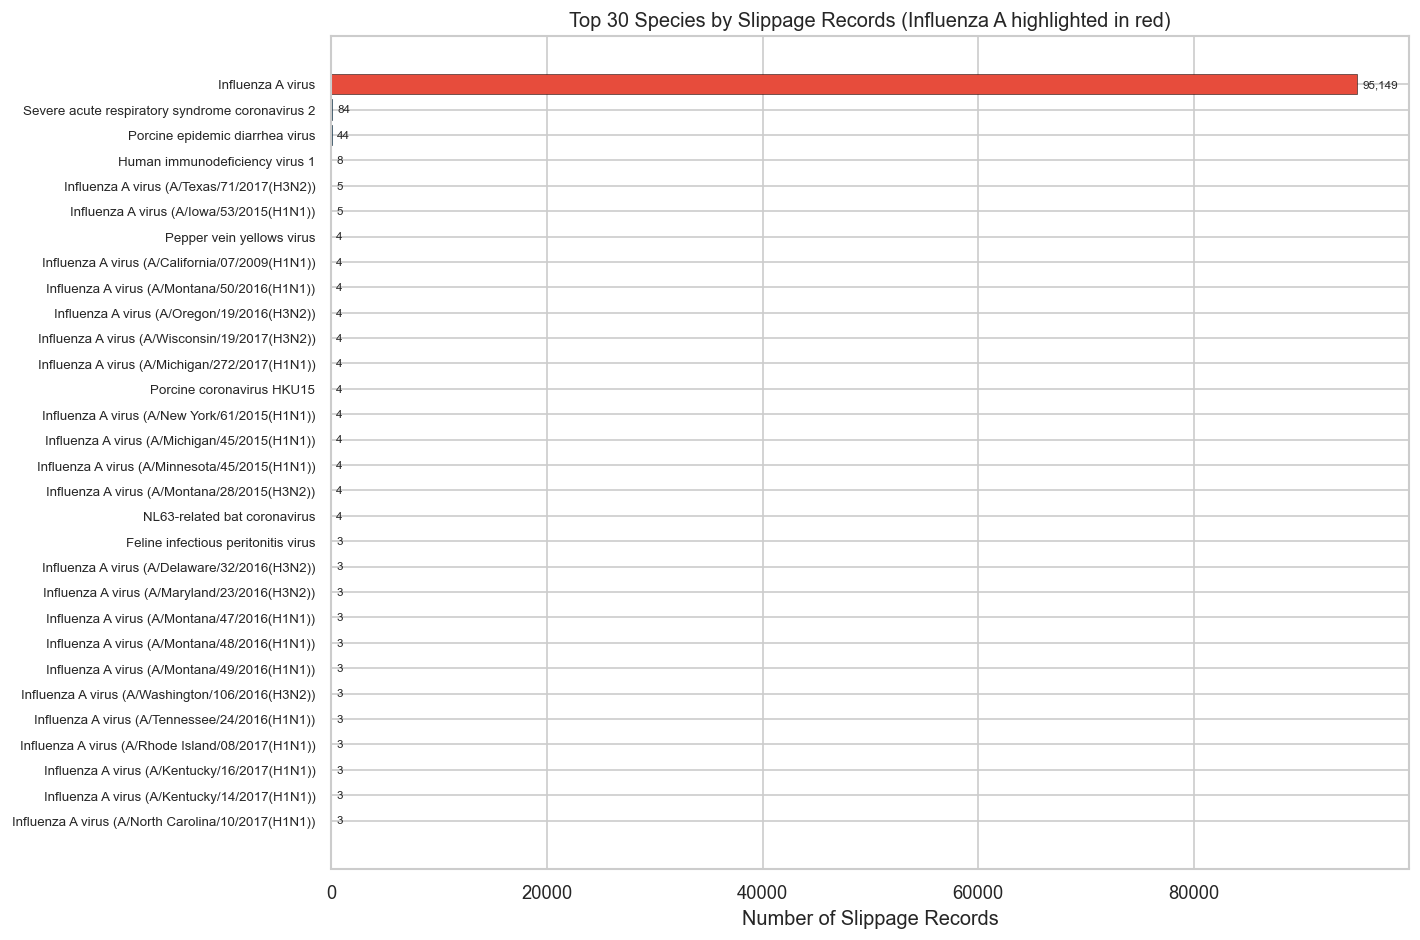

In [ ]:
# Top species by record count, highlighting Influenza A
top_species = species_counts.head(30)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if name == 'Influenza A virus' else '#3498db' for name in top_species.index]
bars = ax.barh(range(len(top_species)), top_species.values, color=colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels(top_species.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Number of Slippage Records')
ax.set_title('Top 30 Species by Slippage Records (Influenza A highlighted in red)')
for i, (bar, count) in enumerate(zip(bars, top_species.values)):
    ax.text(bar.get_width() + max(top_species.values) * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va='center', fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Subsetting strategies for Influenza A
# Compare proportions at different subsample levels
print("=== Subsetting Strategy Options ===")
print()

# Option 1: Keep everything
print(f"Option 1 — No subsetting:")
print(f"  Flu A: {n_flu:,} records ({n_flu/n_total*100:.1f}%)")
print(f"  Others: {n_other:,} records ({n_other/n_total*100:.1f}%)")
print()

# Compute the median # of records per species (excluding Flu A) for a fair baseline
records_per_species = df[~is_flu_a].groupby('organism_name').size()
median_records = records_per_species.median()
mean_records = records_per_species.mean()

print(f"Non-Flu-A species: median records per species = {median_records:.0f}, mean = {mean_records:.1f}")
print()

# Option 2: Subsample Flu A to match median
print(f"Option 2 — Subsample Flu A to median ({median_records:.0f} records):")
n_flu_sub = int(median_records)
n_total_sub = n_other + n_flu_sub
print(f"  Flu A: {n_flu_sub:,} records ({n_flu_sub/n_total_sub*100:.1f}%)")
print(f"  Others: {n_other:,} records ({n_other/n_total_sub*100:.1f}%)")
print(f"  Total: {n_total_sub:,}")
print()

# Option 3: Subsample Flu A to max of other species
max_other = records_per_species.max()
print(f"Option 3 — Subsample Flu A to max of non-Flu species ({max_other:,} records):")
n_flu_sub3 = int(max_other)
n_total_sub3 = n_other + n_flu_sub3
print(f"  Flu A: {n_flu_sub3:,} records ({n_flu_sub3/n_total_sub3*100:.1f}%)")
print(f"  Others: {n_other:,} records ({n_other/n_total_sub3*100:.1f}%)")
print(f"  Total: {n_total_sub3:,}")
print()

# Option 4: Remove Flu A entirely
print(f"Option 4 — Exclude Flu A entirely:")
print(f"  Others: {n_other:,} records (100%)")
print(f"  Total: {n_other:,}")

=== Subsetting Strategy Options ===

Option 1 — No subsetting:
  Flu A: 95,149 records (76.2%)
  Others: 29,729 records (23.8%)

Non-Flu-A species: median records per species = 1, mean = 1.1

Option 2 — Subsample Flu A to median (1 records):
  Flu A: 1 records (0.0%)
  Others: 29,729 records (100.0%)
  Total: 29,730

Option 3 — Subsample Flu A to max of non-Flu species (84 records):
  Flu A: 84 records (0.3%)
  Others: 29,729 records (99.7%)
  Total: 29,813

Option 4 — Exclude Flu A entirely:
  Others: 29,729 records (100%)
  Total: 29,729


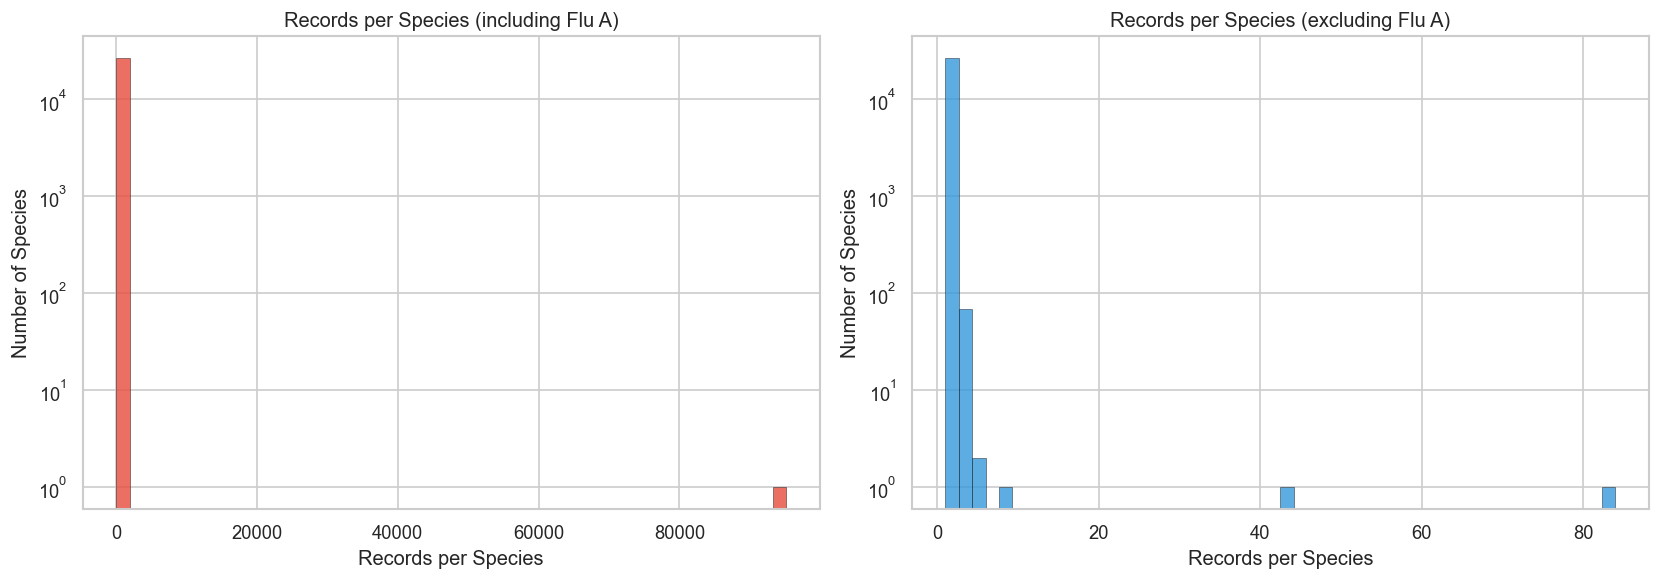

In [ ]:
# Visual: records per species distribution with/without Flu A
all_records_per_species = df.groupby('organism_name').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_records_per_species.values, bins=50, color='#e74c3c', edgecolor='black',
             linewidth=0.3, alpha=0.8)
axes[0].set_xlabel('Records per Species')
axes[0].set_ylabel('Number of Species')
axes[0].set_title('Records per Species (including Flu A)')
axes[0].set_yscale('log')

axes[1].hist(records_per_species.values, bins=50, color='#3498db', edgecolor='black',
             linewidth=0.3, alpha=0.8)
axes[1].set_xlabel('Records per Species')
axes[1].set_ylabel('Number of Species')
axes[1].set_title('Records per Species (excluding Flu A)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
clusters_only = df[df['cluster'] == df['record_id']]

cluster_is_flu_a = clusters_only['organism_name'].str.contains('Influenza A', case=False, na=False)
n_flu = cluster_is_flu_a.sum()
n_total = len(clusters_only)
n_other = n_total - n_flu

print(f"Influenza A virus records: {n_flu:,} ({n_flu/n_total*100:.1f}%)")
print(f"All other species records: {n_other:,} ({n_other/n_total*100:.1f}%)")
print(f"Total records:            {n_total:,}")

# Flu A unique assemblies
flu_asm = clusters_only[cluster_is_flu_a]['accession'].nunique()
other_asm = clusters_only[~cluster_is_flu_a]['accession'].nunique()
total_asm = clusters_only['accession'].nunique()

print(f"\nInfluenza A unique assemblies: {flu_asm:,} ({flu_asm/total_asm*100:.1f}%)")
print(f"Other species unique assemblies: {other_asm:,} ({other_asm/total_asm*100:.1f}%)")

# Flu A unique species count
flu_species = clusters_only[cluster_is_flu_a]['organism_name'].nunique()
other_species = clusters_only[~cluster_is_flu_a]['organism_name'].nunique()
print(f"\nFlu A variants: {flu_species:,} out of {clusters_only['organism_name'].nunique():,} total species/strains")

Influenza A virus records: 959 (23.4%)
All other species records: 3,142 (76.6%)
Total records:            4,101

Influenza A unique assemblies: 959 (23.4%)
Other species unique assemblies: 3,141 (76.6%)

Flu A variants: 167 out of 3,285 total species/strains


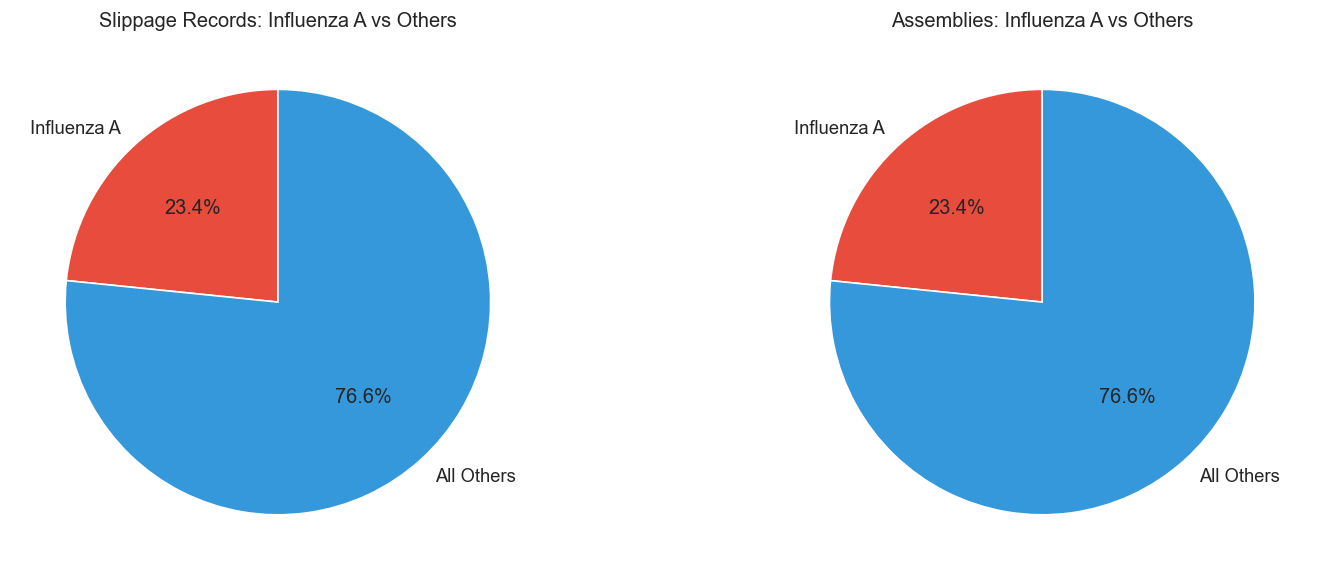

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records pie
axes[0].pie([n_flu, n_other], labels=['Influenza A', 'All Others'],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Slippage Records: Influenza A vs Others')

# Assemblies pie
axes[1].pie([flu_asm, other_asm], labels=['Influenza A', 'All Others'],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Assemblies: Influenza A vs Others')

plt.tight_layout()
plt.show()

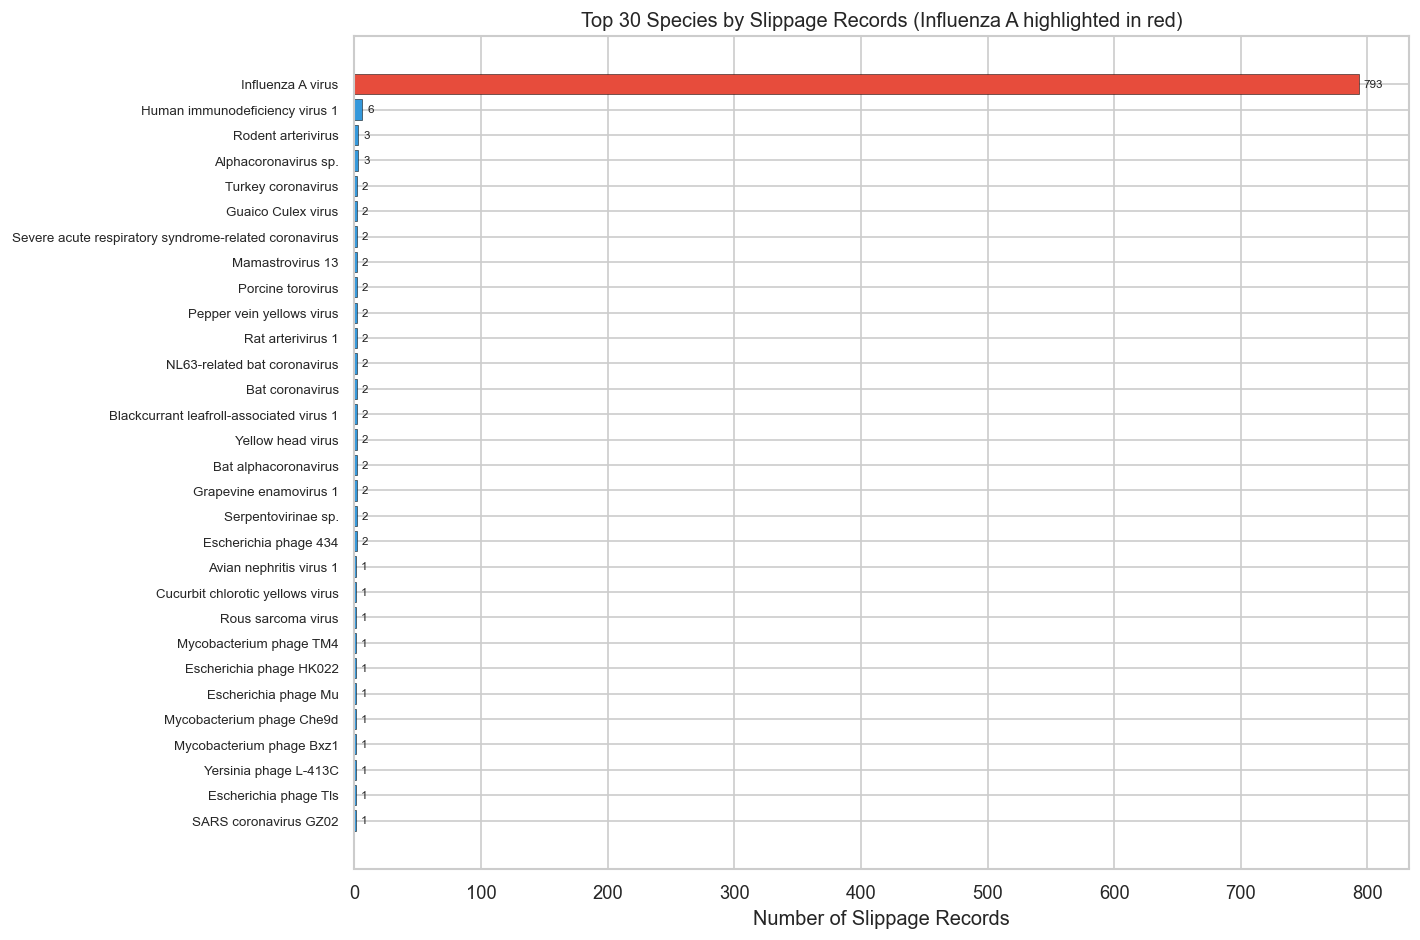

In [ ]:
# Top species by record count, highlighting Influenza A
species_counts = clusters_only['organism_name'].value_counts()
top_species = species_counts.head(30)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if 'Influenza A' in str(name) else '#3498db' for name in top_species.index]
bars = ax.barh(range(len(top_species)), top_species.values, color=colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels(top_species.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Number of Slippage Records')
ax.set_title('Top 30 Species by Slippage Records (Influenza A highlighted in red)')
for i, (bar, count) in enumerate(zip(bars, top_species.values)):
    ax.text(bar.get_width() + max(top_species.values) * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va='center', fontsize=7)
plt.tight_layout()
plt.show()

In [7]:
combined.strand.value_counts()

strand
 1    124822
-1        56
Name: count, dtype: int64